# Mineração de Dados - Rating Prediction Challenge

* Escola Superior de Tecnologia
* Alunos: Thiago Cordeiro de Melo (tcdm.eng23@uea.edu.br)
* Data: 26 de março de 2026

## Descrição

A atividade consiste em desenvolver um modelo de Machine Learning para classificar ratings a partir de textos. Para isso, serão utilizadas técnicas de extração de características linguísticas interpretáveis e modelos clássicos da biblioteca Scikit-learn, como SVM, permitindo analisar os comentários e prever automaticamente o rating associado a cada instância.




In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from prettytable import PrettyTable

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [42]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.head()

,id,ASIN,text,title,rating
0,17578,B07FSVFWDS,"Por incrível que pareça, para uma bebida desti...",Vodka diferenciada,5
1,18658,B08ZHC4VNJ,"O readset pode até ser bom, mais tem outros fo...",Absurdo,1
2,28477,8545202539,"Foi difícil terminar esse livro , demorou mese...",Decepção,2
3,43638,B0081Z77YI,"A bola é boa divertida, mas não é nem um pouco...","Não é indicada para cães grandes, nem mesmo a ...",2
4,26130,857860184X,Comprei errado! Não tenho leitor de e-books. Q...,Enganei,1


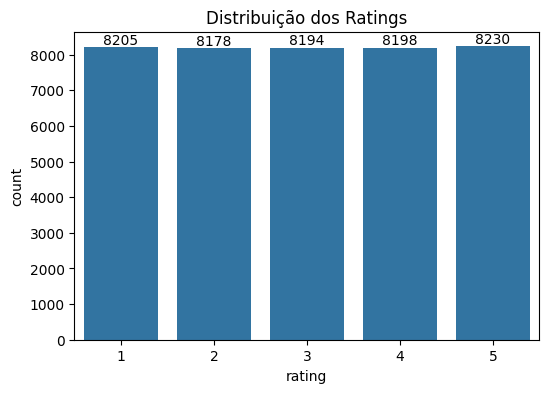

In [43]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='rating', data=train)

plt.title('Distribuição dos Ratings')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')

plt.show()

In [44]:
tabela = PrettyTable()
tabela.field_names = ["Rating", "Exemplo de Avaliação"]

tabela.align["Exemplo de Avaliação"] = "l"
tabela._max_width = {"Exemplo de Avaliação": 100}
tabela.hrules = True 

for r in sorted(train.rating.unique()):
    exemplo_texto = train[train.rating == r].text.iloc[0]
    tabela.add_row([r, exemplo_texto])

print("Exemplos de avaliações por rating:")
print(tabela)

Exemplos de avaliações por rating:
+--------+------------------------------------------------------------------------------------------------------+
| Rating | Exemplo de Avaliação                                                                                 |
+--------+------------------------------------------------------------------------------------------------------+
|   1    | O readset pode até ser bom, mais tem outros fones no mesmo nível que custam mais baratos, na faixa   |
|        | de R$ 600 a R$ 700 reais, uma pena que veio para o Brasil com esse abuso de preço. Um absurdo isso!  |
+--------+------------------------------------------------------------------------------------------------------+
|   2    | Foi difícil terminar esse livro , demorou meses ,  cansativo e nada prático,  78% desse livro        |
|        | comentários ou citação de outros livros e mestres. ( nada prático) o restante do próprio autor nada  |
|        | realmente fosse útil  . Eu achei casos cit

In [45]:
def text_length(text):
    return len(text)

def word_count(text):
    return len(text.split())

def avg_word_length(text):

    words = text.split()

    if len(words) == 0:
        return 0

    return sum(len(w) for w in words) / len(words)

def exclamation_count(text):
    return text.count("!")

def question_count(text):
    return text.count("?")

def dot_count(text):
    return text.count(".")

def comma_count(text):
    return text.count(",")

def capital_ratio(text):

    letters = [c for c in text if c.isalpha()]

    if len(letters) == 0:
        return 0

    caps = sum(1 for c in letters if c.isupper())

    return caps / len(letters)

In [46]:
positive_words = [

"bom","boa","bons","boas",
"ótimo","ótima","ótimos","ótimas",
"excelente","excelentes","incrível","incríveis",
"maravilhoso","maravilhosa","maravilhosos","maravilhosas",
"fantástico","fantástica","fantásticos","fantásticas",
"perfeito","perfeita","perfeitos","perfeitas",
"gostei","gostar","adoro","adorei",
"adoramos","amei","amar","amo",
"satisfeito","satisfeita","satisfeitos","recomendo",
"recomendado","recomendada","recomendável","agradável",
"agradáveis","positivo","positiva","eficiente",
"eficientes","rápido","rápida","rápidos",
"fácil","fáceis","funciona","funcionou",
"bonito","bonita","bonitos","bonitas",
"lindo","linda","legal","confiável",
"impressionante","top","amável","brilhante",
"espetacular","encantador","fantasia","surpreendente",
"melhor","melhores"

]

negative_words = [

"ruim","ruins","péssimo","péssima",
"péssimos","péssimas","horrível","horríveis",
"terrível","terríveis","odiei","odiar",
"odeio","detestei","detestar","pior",
"piores","decepcionante","decepcionado","decepcionada",
"decepcionou","insatisfeito","insatisfeita","lento",
"lenta","lentos","difícil","difíceis",
"problema","problemas","erro","erros",
"falha","falhas","bug","bugs",
"defeito","defeitos","quebrado","quebrada",
"caro","cara","caros","caras",
"enganoso","enganado","enganada","horrendo",
"desagradável","fraco","fraca","triste",
"insuportável","ridículo","inútil","deplorável",
"lamentável","absurdo","frustrante","irritante",
"demorado","terrível","pessimo","pessima"

]

In [47]:
def positive_word_count(text):

    words = text.lower().split()

    return sum(word in positive_words for word in words)

def negative_word_count(text):

    words = text.lower().split()

    return sum(word in negative_words for word in words)

In [50]:
def number_count(text):

    return sum(c.isdigit() for c in text)

def unique_word_count(text):

    words = text.lower().split()

    return len(set(words))

def unique_ratio(text):

    words = text.lower().split()

    if len(words) == 0:
        return 0

    return len(set(words)) / len(words)

def max_word_length(text):

    words = text.split()

    if len(words) == 0:
        return 0

    return max(len(w) for w in words)

def avg_words_per_sentence(text):

    sentences = re.split(r"[.!?]", text)

    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

    if len(sentences) == 0:
        return 0

    word_counts = [len(s.split()) for s in sentences]

    return sum(word_counts) / len(sentences)

In [53]:
def extract_features(text):

    if not isinstance(text, str):
        text = ""

    return [
        text_length(text),
        word_count(text),
        avg_word_length(text),
        exclamation_count(text),
        question_count(text),
        dot_count(text),
        capital_ratio(text),
        positive_word_count(text),
        negative_word_count(text),
        comma_count(text),
        number_count(text),
        unique_word_count(text),
        unique_ratio(text),
        max_word_length(text),
        avg_words_per_sentence(text)
    ]

In [54]:
X_train = np.array(train.text.apply(extract_features).tolist())
y_train = train.rating

X_test = np.array(test.text.apply(extract_features).tolist())

In [55]:
feature_names = [
    "text_length",
    "word_count",
    "avg_word_length",
    "exclamation_count",
    "question_count",
    "dot_count",
    "capital_ratio",
    "positive_words",
    "negative_words",
    "comma_count",
    "number_count",
    "unique_words",
    "unique_ratio",
    "max_word_length",
    "avg_words_sentence"
]

df_features = pd.DataFrame(X_train, columns=feature_names)

df_features.head()

,text_length,word_count,avg_word_length,exclamation_count,question_count,dot_count,capital_ratio,positive_words,negative_words,comma_count,number_count,unique_words,unique_ratio,max_word_length,avg_words_sentence
0,216.0,35.0,5.200000,0.0,0.0,4.0,0.022989,1.0,0.0,4.0,0.0,32.0,0.914286,12.0,9.00
1,198.0,41.0,3.853659,1.0,0.0,1.0,0.034483,0.0,1.0,3.0,6.0,36.0,0.878049,8.0,20.50
2,340.0,59.0,4.728814,0.0,0.0,4.0,0.014981,0.0,1.0,3.0,2.0,48.0,0.813559,11.0,14.25
3,109.0,21.0,4.238095,1.0,0.0,1.0,0.023256,1.0,0.0,1.0,0.0,18.0,0.857143,13.0,10.50
4,110.0,20.0,4.550000,2.0,0.0,4.0,0.048780,0.0,0.0,0.0,0.0,18.0,0.900000,10.0,4.00


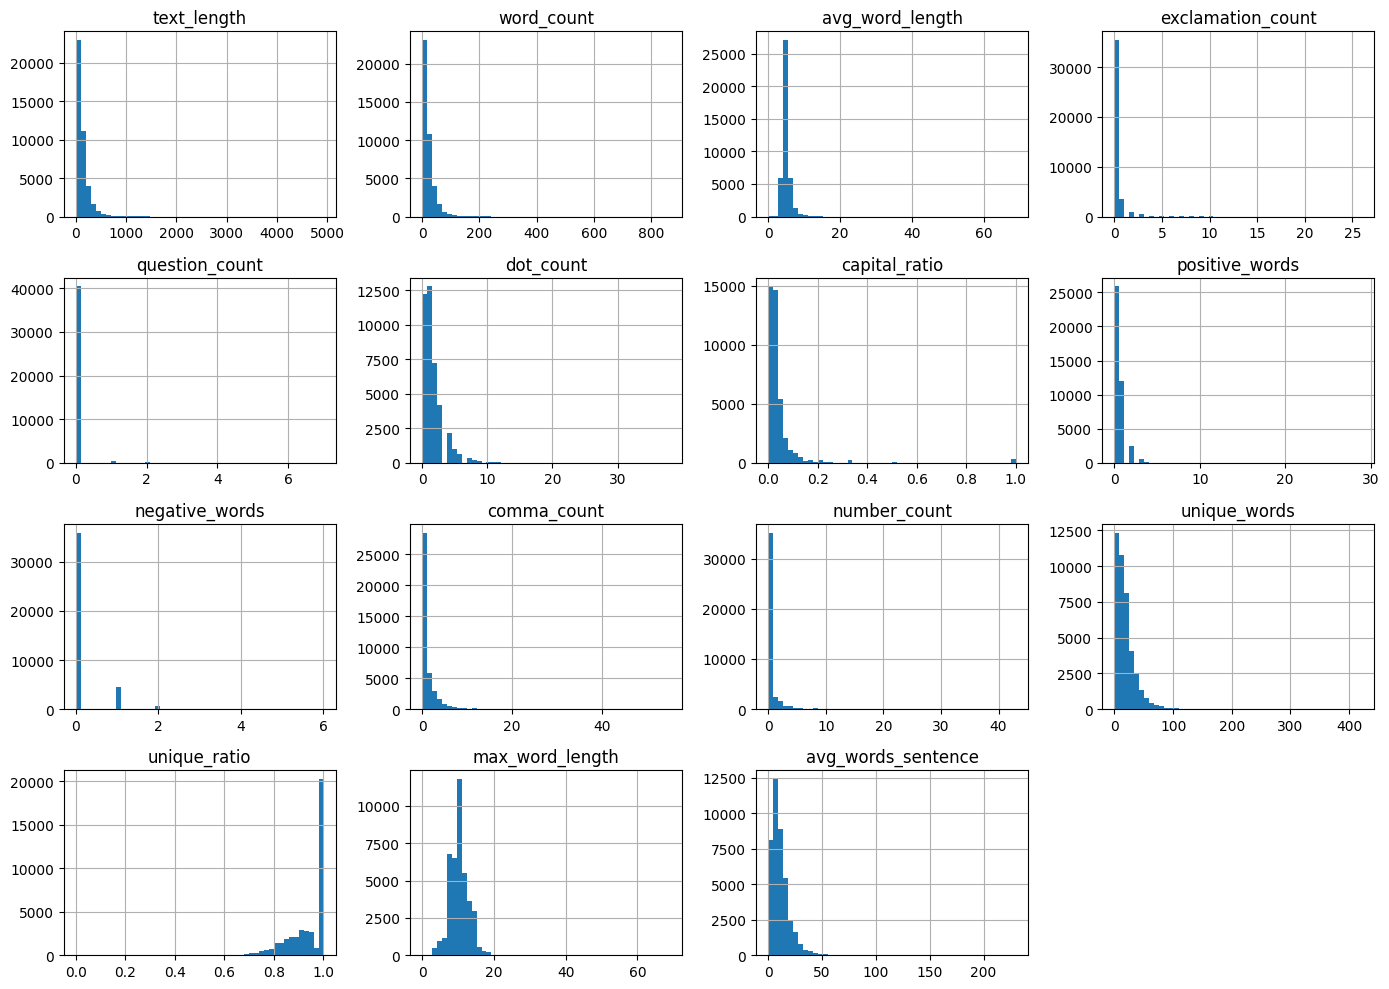

In [59]:
df_features.hist(figsize=(14,10), bins=50)
plt.tight_layout()
plt.show()

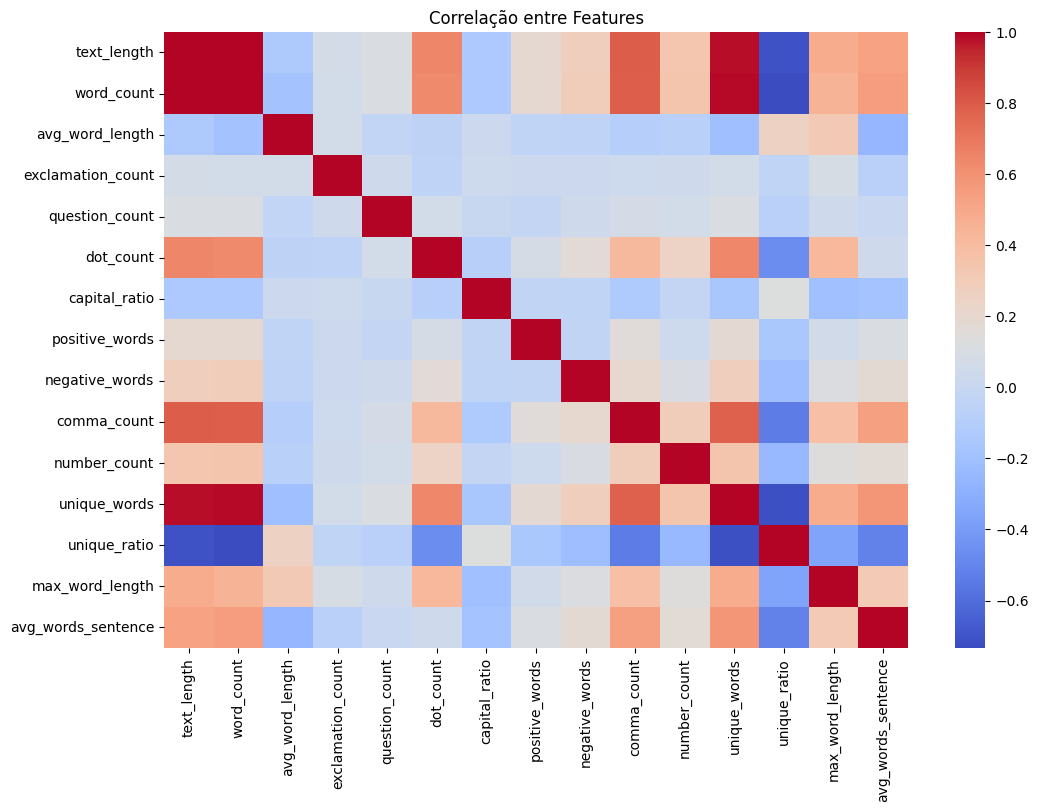

In [60]:
plt.figure(figsize=(12,8))
sns.heatmap(df_features.corr(), cmap="coolwarm", annot=False)
plt.title("Correlação entre Features")
plt.show()

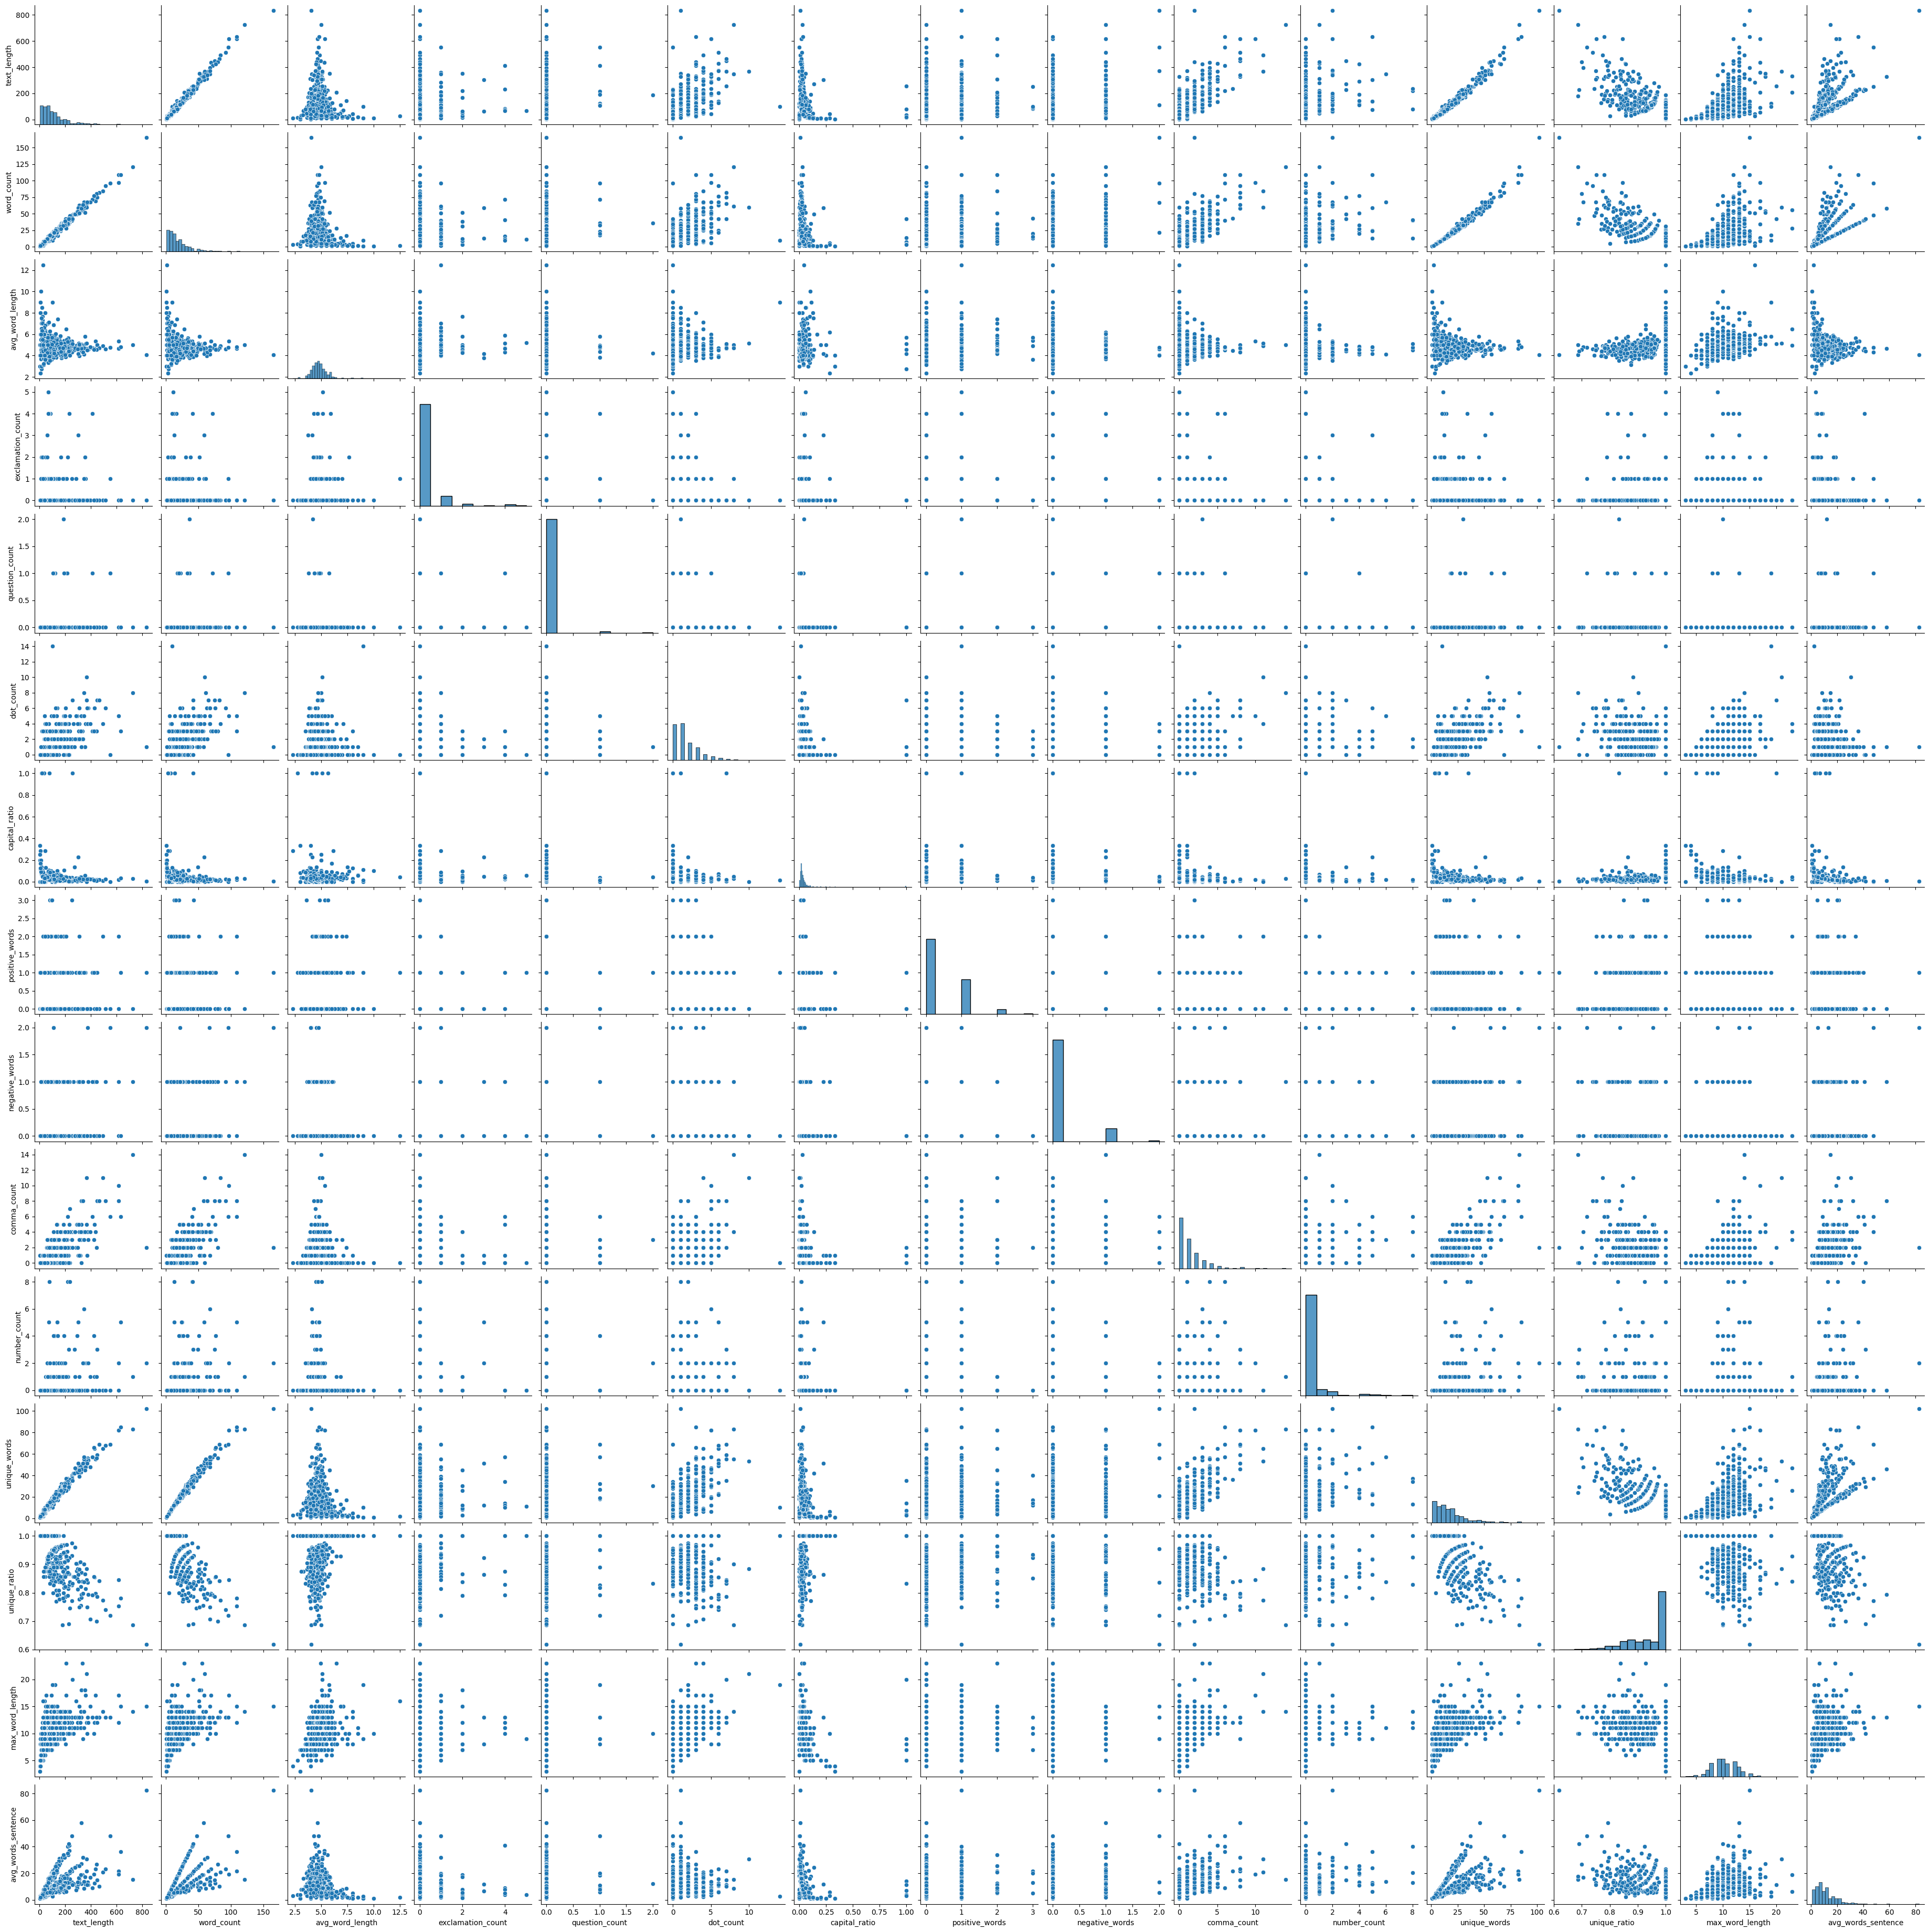

In [62]:
sns.pairplot(df_features.sample(500))
plt.show()

In [63]:
df_features.describe()

,text_length,word_count,avg_word_length,exclamation_count,question_count,dot_count,capital_ratio,positive_words,negative_words,comma_count,number_count,unique_words,unique_ratio,max_word_length,avg_words_sentence
count,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000,41005.000000
mean,121.362834,21.305743,4.967397,0.231313,0.019168,1.579466,0.045784,0.465480,0.140349,1.300110,0.386026,18.649189,0.936859,10.304816,11.297260
std,129.478092,22.805824,1.127100,0.769837,0.197223,1.847230,0.100840,0.715922,0.403601,1.918931,1.403312,16.927993,0.078410,2.719637,9.107167
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,43.000000,7.000000,4.357143,0.000000,0.000000,0.000000,0.015625,0.000000,0.000000,0.000000,0.000000,7.000000,0.888889,9.000000,5.333333
50%,85.000000,15.000000,4.777778,0.000000,0.000000,1.000000,0.025381,0.000000,0.000000,1.000000,0.000000,14.000000,0.966667,10.000000,9.000000
75%,156.000000,28.000000,5.333333,0.000000,0.000000,2.000000,0.042553,1.000000,0.000000,2.000000,0.000000,25.000000,1.000000,12.000000,14.500000
max,4930.000000,865.000000,69.000000,26.000000,7.000000,38.000000,1.000000,29.000000,6.000000,55.000000,43.000000,422.000000,1.000000,69.000000,230.000000


In [64]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
model = SVC(kernel="rbf", random_state=42)

In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kf,
    scoring="accuracy"
)

print(scores)